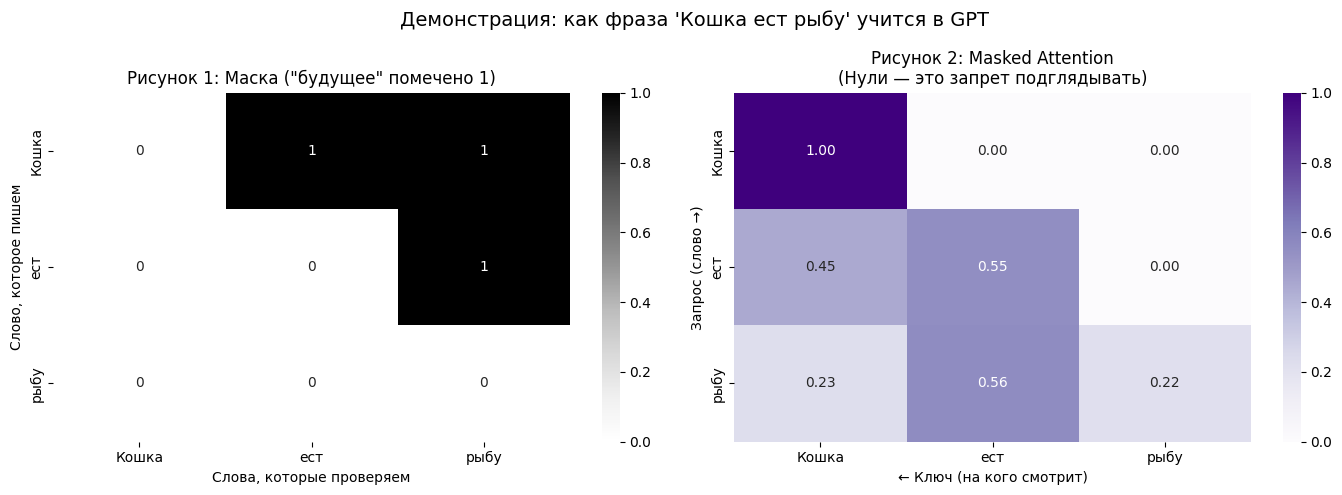


Интерпретация:
- Слово 'Кошка' (1-я строка) видит только: ['Кошка']
- Слово 'ест' (2-я строка) видит только: ['Кошка', 'ест']
- Слово 'рыбу' (3-я строка) видит только: ['Кошка', 'ест', 'рыбу']

Так GPT учится генерировать текст по одному слову, не видя будущего.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1): 
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True) 

def masked_attention_demo(words):
    seq_len = len(words)
    d_k = 4 # размерность вектора
    np.random.seed(42) 
    Q = np.random.randn(seq_len, d_k) #матрица 3 на 4, слова и их 4 признака
    K = np.random.randn(seq_len, d_k)
    V = np.random.randn(seq_len, d_k)

    # Считаем сырые оценки (scores)
    scores = Q @ K.T / np.sqrt(d_k) # Деление, без него разница между числами будет слишком большой, и Softmax "зашкалит", отдав 100% внимания одному слову.
    
    #Создаем треугольную маску
    mask = np.triu(np.ones((seq_len, seq_len)), k=1) #triu обнуляет все что находится выше главное диагонали (k)
    # 0 - можно смотреть
    # 1 - нельзя смотреть

    #
    scores_masked = scores.copy()
    scores_masked[mask == 1] = -1e9 #Чтобы в softmax было 0 внимания для будущего, матрица признаков с нулями в соответствии с матрицей mask
    
    # Считаем финальные веса через Softmax
    # После Softmax все -1e9 превратятся в чистые нули!
    weights = softmax(scores_masked, axis=-1)


    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
    # Карта 1
    sns.heatmap(mask, annot=True, fmt='.0f', #тепловая карта
                xticklabels=words, yticklabels=words,
                cmap='Greys', ax=axes[0])
    
    axes[0].set_title('Рисунок 1: Маска ("будущее" помечено 1)')
    axes[0].set_ylabel('Слово, которое пишем')
    axes[0].set_xlabel('Слова, которые проверяем')

    # Карта 2
    sns.heatmap(weights, annot=True, fmt='.2f',
                xticklabels=words, yticklabels=words,
                cmap='Purples', ax=axes[1], cbar=True, vmin=0, vmax=1)
    axes[1].set_title('Рисунок 2: Masked Attention\n(Нули — это запрет подглядывать)')
    axes[1].set_ylabel('Запрос (слово →)')
    axes[1].set_xlabel('← Ключ (на кого смотрит)')
    
    plt.suptitle(f"Демонстрация: как фраза '{' '.join(words)}' учится в GPT", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nИнтерпретация:")
    print(f"- Слово 'Кошка' (1-я строка) видит только: ['Кошка']")
    print(f"- Слово 'ест' (2-я строка) видит только: ['Кошка', 'ест']")
    print(f"- Слово 'рыбу' (3-я строка) видит только: ['Кошка', 'ест', 'рыбу']")
    print("\nТак GPT учится генерировать текст по одному слову, не видя будущего.")

words = ['Кошка', 'ест', 'рыбу']
masked_attention_demo(words)